In [11]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

import os
print(os.getcwd())

/Users/eoghankealy/Documents/data_projects/hotel_bookings


In [13]:
# Use only the filename of  CSV file
df = pd.read_csv('train_logistic_regression_for_python_v2.csv') 

# Display the first few rows to verify
print(df.head())

   is_canceled  lead_time_std   adr_std  no_deposit  prev_cancellations  \
0            0      -0.882085 -0.339170           1                   0   
1            0      -0.819588 -0.339170           1                   0   
2            0      -0.809172  0.079986           1                   0   
3            0      -0.809172  0.079986           1                   0   
4            0      -0.954998  0.244003           1                   0   

   repeat_guest  market_corporate  market_onlineTA  market_offlineTA/TO  \
0             0                 0                0                    0   
1             0                 1                0                    0   
2             0                 0                1                    0   
3             0                 0                1                    0   
4             0                 0                0                    0   

   market_groups  market_comp  booking_changes_flag  booking_changes_std  \
0              0      

In [15]:
import statsmodels.api as sm

# Y is the Actual Outcome (is_canceled from Excel)
Y = df["is_canceled"]

# X is the list of all standardized predictor columns ( intercept  through to  last predictor)
#  replace these placeholder names with the EXACT column headers from CSV
X_cols = [
    'lead_time_std', 'adr_std', 'no_deposit', 'prev_cancellations',
    'repeat_guest', 'market_corporate', 'market_onlineTA',
    'market_offlineTA/TO', 'market_groups', 'market_comp',
    'booking_changes_flag','special_requests', 'national'  
]

X = df[X_cols]

#  add intercept:
X = sm.add_constant(X)

# Create the Logit model object
logit_model = sm.Logit(Y, X)

# Fit the model (solves for the optimal coefficients instantly)
results = logit_model.fit()

# Print the full summary—this contains the final, precise coefficients
print(results.summary())


Optimization terminated successfully.
         Current function value: 0.378565
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                24851
Model:                          Logit   Df Residuals:                    24837
Method:                           MLE   Df Model:                           13
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.3509
Time:                        17:36:53   Log-Likelihood:                -9407.7
converged:                       True   LL-Null:                       -14494.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.5083      0.124     -4.107      0.000      -0.751      -0.266

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

                 feature        VIF
0                  const  36.488692
1          lead_time_std   1.365695
2                adr_std   1.150482
3             no_deposit   1.442432
4     prev_cancellations   1.137759
5           repeat_guest   1.104245
6       market_corporate   1.320127
7        market_onlineTA   2.244226
8    market_offlineTA/TO   2.025213
9          market_groups   2.446869
10           market_comp   1.054084
11  booking_changes_flag   1.053646
12      special_requests   1.269369
13              national   1.126232


In [19]:

# Import functions for ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [21]:
# Y is the actual outcome (is_canceled)
# X is the matrix of predictors + constant

# Calculate predicted probabilities (BD column in Excel)
y_probabilities = results.predict(X)


In [23]:
# Calculate FPR (x-axis), TPR (y-axis), and the thresholds
# Y is the Actual Outcome (is_canceled), y_probabilities are the predicted risks
fpr, tpr, thresholds = roc_curve(Y, y_probabilities)

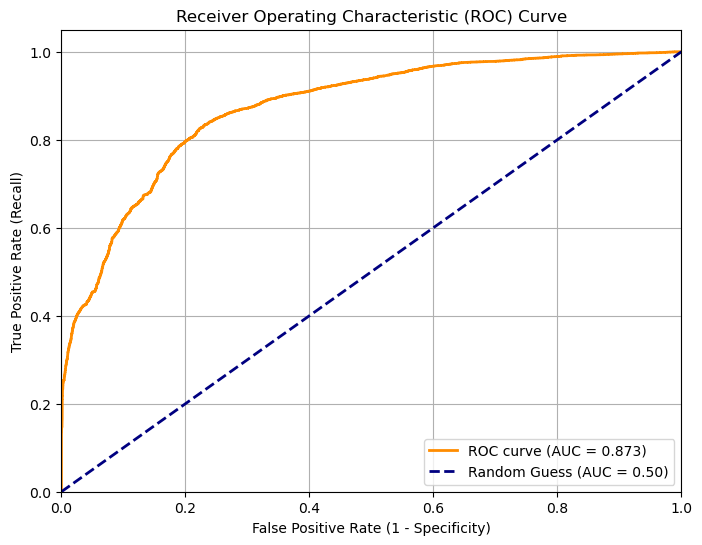

In [25]:
# Calculate the Area Under the Curve (AUC) score
roc_auc = roc_auc_score(Y, y_probabilities)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [27]:
# Testing the mdoel on 2017 data

# 1. Load the prepared 2017 Test Data CSV file
test_df = pd.read_csv('test_2017_data_logistic_regression_v2.csv')

# 2. Separate the actual outcome (Y_test_actual)
# Ensure 'is_canceled' is present in test data for evaluation
Y_test_actual = test_df['is_canceled']

# 3. Features used for prediction (X_test)
# drop the actual outcome column
X_test = test_df.drop(columns=['is_canceled'])


In [29]:
print(test_df.head())

   is_canceled  repeat_guest  national  special_requests  no_deposit  \
0            1             0         1                 0           1   
1            1             0         0                 1           1   
2            1             0         0                 1           1   
3            1             0         0                 1           1   
4            1             0         0                 1           1   

   booking_changes_flag  prev_cancellations  lead_time_std   adr_std  \
0                     0                   0      -0.184205 -0.656271   
1                     0                   0      -0.309198 -0.767439   
2                     0                   0      -0.309198 -0.767439   
3                     0                   0      -0.309198 -0.767439   
4                     0                   0      -0.038379 -0.892456   

   market_onlineTA  market_offlineTA/TO  market_groups  market_corporate  \
0                1                    0              0    

In [31]:
# The EXACT list of feature columns (excluding the intercept, which will be added)
X_cols_no_const = [
    'lead_time_std', 'adr_std', 'no_deposit', 'prev_cancellations',
    'repeat_guest', 'market_corporate', 'market_onlineTA',
    'market_offlineTA/TO', 'market_groups', 'market_comp',
    'booking_changes_flag','special_requests', 'national' 
]



In [33]:
# Ensure the columns are in the correct order BEFORE adding the constant
X_test_ordered = X_test[X_cols_no_const]

In [35]:
# Add the constant term ('const') to match the training model's structure

X_test_with_const = sm.add_constant(X_test_ordered)

In [37]:
# Generate Predicted Probabilities
#  use the .predict() method on the fitted results object
predictions_proba = results.predict(X_test_with_const)

# Convert probabilities to binary outcomes (0 or 1) using a 0.5 threshold
Y_test_predicted = (predictions_proba >= 0.5).astype(int)

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Accuracy Score
accuracy = accuracy_score(Y_test_actual, Y_test_predicted)
print(f"✅ Model Accuracy on 2017 Test Data: {accuracy:.4f}\n")

# 2. Confusion Matrix
# breaks down correct/incorrect predictions (True Positive, False Positive, etc.)
conf_matrix = confusion_matrix(Y_test_actual, Y_test_predicted)
print("Confusion Matrix:")
print(conf_matrix)

# 3. Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report (Focus on Precision/Recall for cancellations=1):")
print(classification_report(Y_test_actual, Y_test_predicted))

✅ Model Accuracy on 2017 Test Data: 0.7481

Confusion Matrix:
[[8215  497]
 [2695 1266]]

Classification Report (Focus on Precision/Recall for cancellations=1):
              precision    recall  f1-score   support

           0       0.75      0.94      0.84      8712
           1       0.72      0.32      0.44      3961

    accuracy                           0.75     12673
   macro avg       0.74      0.63      0.64     12673
weighted avg       0.74      0.75      0.71     12673



In [41]:

# Will now try different thresholds

# 1. Create a DataFrame for easier analysis
prob_df = pd.DataFrame({
    'Actual': Y_test_actual, 
    'Probability': predictions_proba
})

# 2. Sort by probability to analyze thresholds
prob_df = prob_df.sort_values(by='Probability', ascending=False).reset_index(drop=True)

In [43]:

# Set the new threshold
new_threshold = 0.35

# Convert probabilities using the new threshold
Y_predicted_new = (predictions_proba >= new_threshold).astype(int)

# Print the results for the new threshold
print(f"--- Results with Threshold = {new_threshold} ---")
print(classification_report(Y_test_actual, Y_predicted_new))

--- Results with Threshold = 0.35 ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      8712
           1       0.63      0.45      0.53      3961

    accuracy                           0.74     12673
   macro avg       0.70      0.66      0.68     12673
weighted avg       0.73      0.74      0.73     12673



In [45]:

# Set the new threshold
new_threshold = 0.40

# Convert probabilities using the new threshold
Y_predicted_new = (predictions_proba >= new_threshold).astype(int)

print(f"--- Results with Threshold = {new_threshold} ---")

# 1. Generate and Print the Confusion Matrix
conf_matrix = confusion_matrix(Y_test_actual, Y_predicted_new)
print("\nConfusion Matrix:")
# The matrix will be printed in the format: [[TN, FP], [FN, TP]]
print(conf_matrix)

# 2. Print the Classification Report
print("\nClassification Report:")
print(classification_report(Y_test_actual, Y_predicted_new))

--- Results with Threshold = 0.4 ---

Confusion Matrix:
[[7929  783]
 [2331 1630]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84      8712
           1       0.68      0.41      0.51      3961

    accuracy                           0.75     12673
   macro avg       0.72      0.66      0.67     12673
weighted avg       0.74      0.75      0.73     12673



In [47]:

# Set the new threshold
new_threshold = 0.30

# Convert probabilities using the new threshold
Y_predicted_new = (predictions_proba >= new_threshold).astype(int)

print(f"--- Results with Threshold = {new_threshold} ---")

# 1. Generate and Print the Confusion Matrix
conf_matrix = confusion_matrix(Y_test_actual, Y_predicted_new)
print("\nConfusion Matrix:")
# The matrix will be printed in the format: [[TN, FP], [FN, TP]]
print(conf_matrix)

# 2. Print the Classification Report
print("\nClassification Report:")
print(classification_report(Y_test_actual, Y_predicted_new))

--- Results with Threshold = 0.3 ---

Confusion Matrix:
[[7469 1243]
 [1924 2037]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      8712
           1       0.62      0.51      0.56      3961

    accuracy                           0.75     12673
   macro avg       0.71      0.69      0.69     12673
weighted avg       0.74      0.75      0.74     12673



In [49]:
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                24851
Model:                          Logit   Df Residuals:                    24837
Method:                           MLE   Df Model:                           13
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.3509
Time:                        17:37:52   Log-Likelihood:                -9407.7
converged:                       True   LL-Null:                       -14494.
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.5083      0.124     -4.107      0.000      -0.751      -0.266
lead_time_std            0.5787      0.021     26.970      0.000       0.537       0.621
adr_std                  0.1686      0.018      9.250      0.000       0.133       0.204
no_deposit              -2.4381      0.107    -22.754      0.000      -2.648      -2.228
prev_cancellations       3.9067      0.185     21.062      0.000       3.543       4.270
repeat_guest            -2.7055      0.206    -13.108      0.000      -3.110      -2.301
market_corporate        -0.0131      0.111     -0.118      0.906      -0.230       0.204
market_onlineTA          1.9258      0.061     31.786      0.000       1.807       2.044
market_offlineTA/TO      0.0650      0.076      0.852      0.394      -0.084       0.215
market_groups            0.5036      0.079      6.367      0.000       0.349       0.659
market_comp              0.4217      0.269      1.570      0.116      -0.105       0.948
booking_changes_flag    -0.9147      0.054    -16.937      0.000      -1.021      -0.809
special_requests        -1.1077      0.043    -25.471      0.000      -1.193      -1.022
national                 2.2589      0.041     55.113      0.000       2.179       2.339
========================================================================================
"""


🟦 14 Variable Model AUC Score on 2017 Test Data: 0.8034


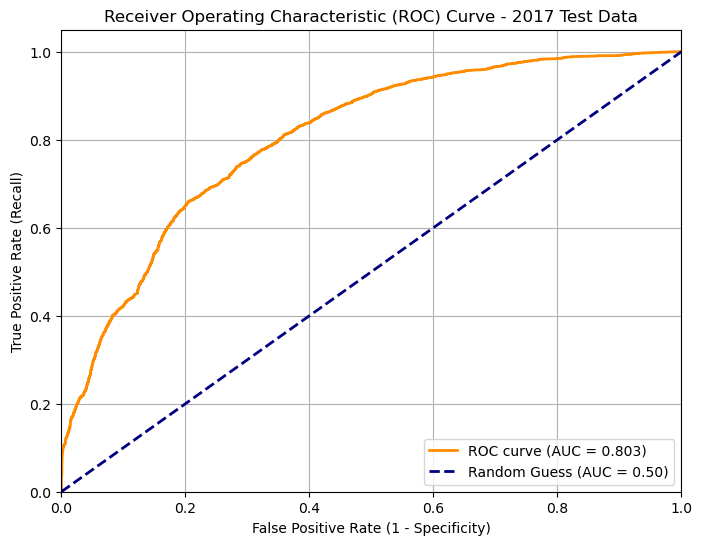

In [61]:
# 1. Calculate FPR, TPR, and thresholds using the test data
fpr, tpr, thresholds = roc_curve(Y_test_actual, predictions_proba)

# 2. Calculate the Area Under the Curve (AUC) score
# We use the known value of 0.8034 for the output description, but the code calculates it
test_roc_auc = roc_auc_score(Y_test_actual, predictions_proba)

 # Print the score for documentation
print(f"\n🟦 14 Variable Model AUC Score on 2017 Test Data: {roc_auc:.4f}")

# 3. Plot the ROC curve with the requested style parameters
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - 2017 Test Data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()




🟦 14 Variable Model AUC Score on 2017 Test Data: 0.8034


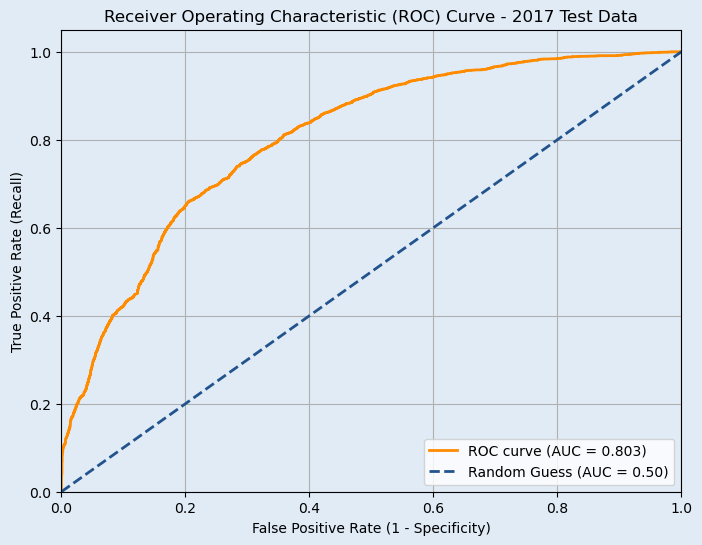

In [91]:
# 1. Calculate FPR, TPR, and thresholds using the test data
fpr, tpr, thresholds = roc_curve(Y_test_actual, predictions_proba)

# 2. Calculate the Area Under the Curve (AUC) score
# We use the known value of 0.8034 for the output description, but the code calculates it
test_roc_auc = roc_auc_score(Y_test_actual, predictions_proba)

 # Print the score for documentation
print(f"\n🟦 14 Variable Model AUC Score on 2017 Test Data: {roc_auc:.4f}")

# 3. Plot the ROC curve with the requested style parameters
plt.figure(figsize=(8, 6))

 # Get the current axes object
ax = plt.gca()

# Set the color of the figure's background (outer canvas) to white for contrast
plt.gcf().set_facecolor('#E0EBF6') 

# Set the color of the plot area background to the exact Excel color: #E0EBF6
ax.set_facecolor('#E0EBF6')

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#22538D', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - 2017 Test Data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()